# Principal Component Analysis

# Import images

In [1]:
import numpy as np
from pathlib import Path
import gzip

# Read info from compressed binary format
BASE_DIR = Path.cwd().parent

# Labels
label_path = BASE_DIR / "MNIST" / 'train-labels-idx1-ubyte.gz'
with gzip.open(label_path, 'rb') as f:
    magic = int.from_bytes(f.read(4)) # First 4 bytes
    n_labels = int.from_bytes(f.read(4)) # Number of labels
    labels = np.frombuffer(f.read(), dtype=np.uint8) # Convert remaining bytes to numpy array

print(f"number of items according to file: {n_labels}")
print(f"actual number of items: {len(labels)}")

# Images
img_path = BASE_DIR / "MNIST" / 'train-images-idx3-ubyte.gz'
with gzip.open(img_path, 'rb') as f:
    magic = int.from_bytes(f.read(4)) # First 4 bytes
    n_images = int.from_bytes(f.read(4)) # Number of images
    n_rows = int.from_bytes(f.read(4))
    n_cols = int.from_bytes(f.read(4))
    pixels = np.frombuffer(f.read(), dtype=np.uint8) # Convert remaining bytes to numpy array

print(f"number of images according to file: {n_labels}")
print(f"n_rows: {n_rows}")
print(f"n_cols: {n_cols}")
print(f"actual number of images: {len(pixels) // (n_rows * n_cols)}")

imgs = pixels.reshape(n_images, n_rows, n_cols)
print(f"number of reshapes images: {len(imgs)}")

number of items according to file: 60000
actual number of items: 60000
number of images according to file: 60000
n_rows: 28
n_cols: 28
actual number of images: 60000
number of reshapes images: 60000


## Show some images

In [2]:
import matplotlib.pyplot as plt

def show_image_grid(imgs, labels, ids, cols=5):
    rows = int(np.ceil(len(ids) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    axes = np.array(axes).reshape(-1)

    for ax, id in zip(axes, ids):
        ax.imshow(imgs[id], cmap='gray')
        ax.axis('off')
        ax.set_title(f"Label: {labels[id]}")

    for ax in axes[len(ids):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

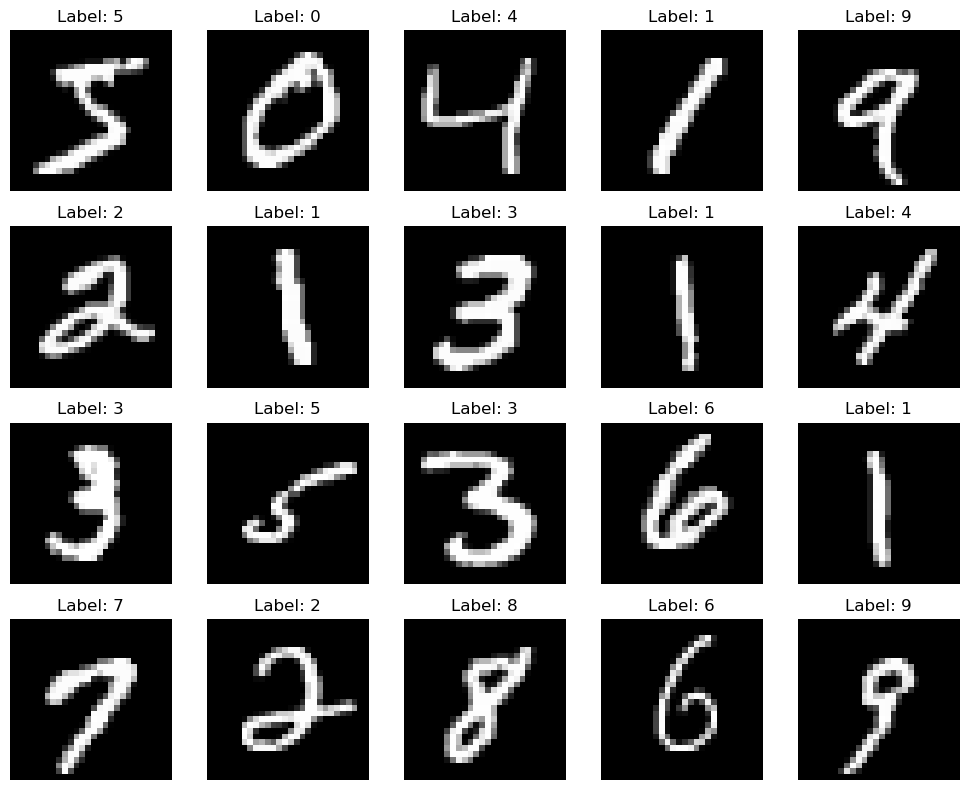

In [3]:
show_image_grid(imgs, labels, ids=range(20), cols=5)

## Filtered after label

5851
5851


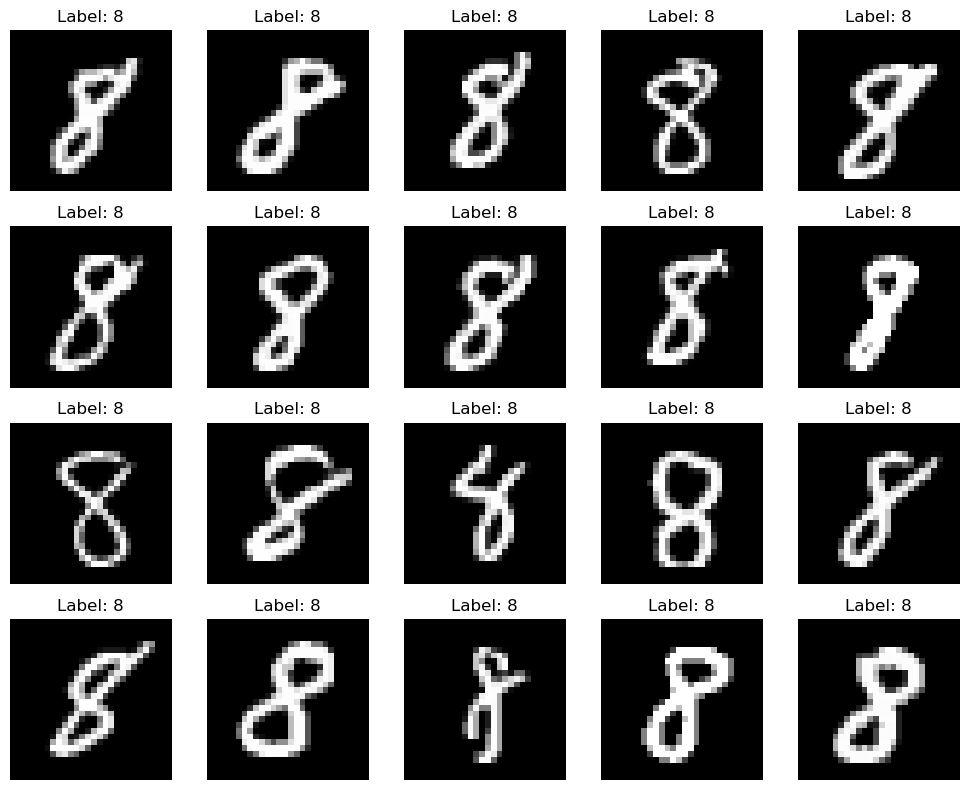

In [4]:
indices = np.where(labels == 8)[0]

filtered_imgs = imgs[indices]
filtered_labels = labels[indices]

print(len(filtered_imgs))
print(len(filtered_labels))

show_image_grid(filtered_imgs, filtered_labels, ids=range(20), cols=5)

# PCA

In [5]:
def MNIST_PCA(imgs, labels):
    # Key steps of PCA:

    # 1. Standardization - mean subtraction and dividing by standard deviation 
    N = imgs.shape[0]
    flat_imgs = imgs.reshape(N, n_cols * n_rows)
    
    mu = np.mean(flat_imgs, axis=0)
    std = np.std(flat_imgs, axis=0)
    std_safe = np.where(std == 0, 1, std)

    standard_flat_imgs = (flat_imgs - mu) / std_safe

    # 2. Compute covariance matrix S = X X.T / N
    X = standard_flat_imgs.T
    S = X @ X.T / N

    eigenvalues, eigenvectors = np.linalg.eigh(S)
    pc1, pc2 = eigenvalues[-1], eigenvalues[-2]
    pcv1, pcv2 = eigenvectors[:, -1], eigenvectors[:, -2]


    # 3. Project onto the principal subspace
    B = np.array([pcv1, pcv2]).T
    
    Z = B.T @ X

    Z = np.append(Z, [labels], axis=0)

    return Z

        
def plot_pca(Z):

    Z = Z.T

    labels = np.unique(Z[:, 2])

    for label in labels:
        label_points = Z[Z[:, 2] == label]
        plt.scatter(
            label_points[:, 0],
            label_points[:, 1],
            label=f"Label: {int(label)}"
        )

    plt.xlabel("Coordinate 1")
    plt.ylabel("Coordinate 2")
    plt.legend()
    plt.show()


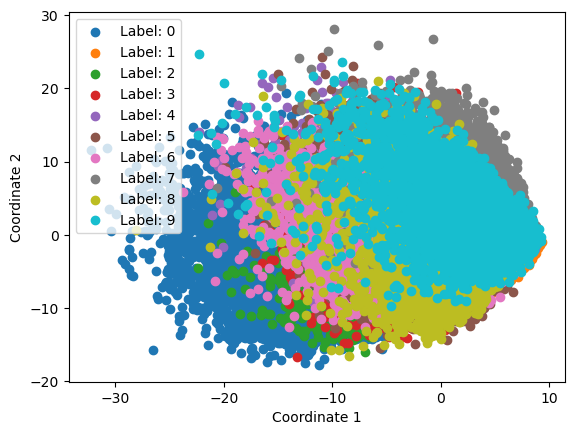

In [6]:
Z = MNIST_PCA(imgs, labels)

plot_pca(Z)

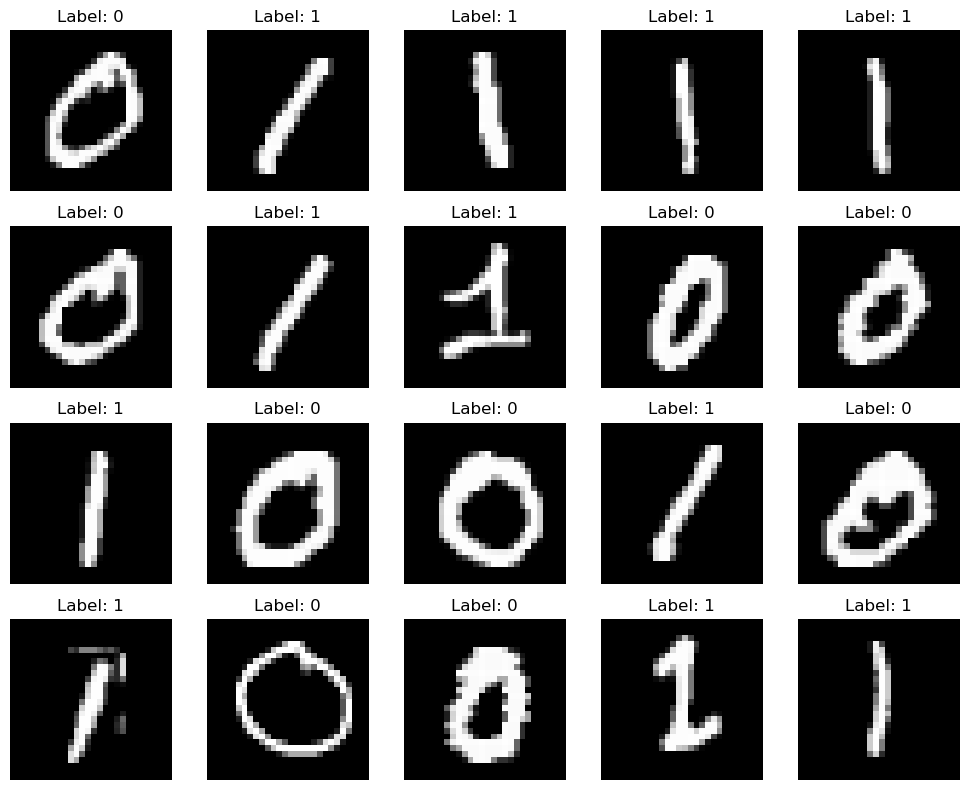

In [7]:
indices = np.where(np.isin(labels, [0, 1]))[0]

filtered_imgs = imgs[indices]
filtered_labels = labels[indices]

show_image_grid(filtered_imgs, filtered_labels, ids=range(20), cols=5)

## PCA for 1s and 0s

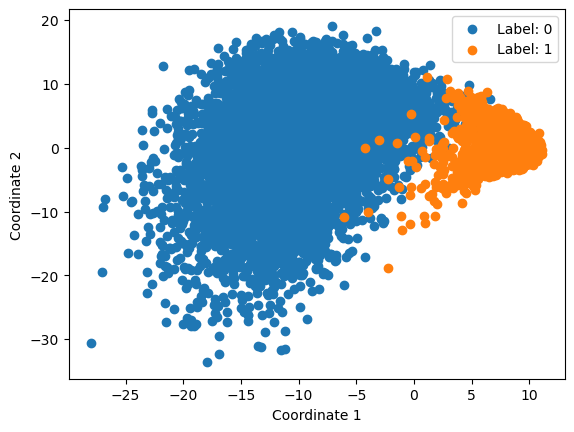

In [8]:
Z = MNIST_PCA(filtered_imgs, filtered_labels)

plot_pca(Z)

In [ ]:
def project_PCA(imgs, dim):
    # 1. Standardization - mean subtraction and dividing by standard deviation 
    N, n_cols, n_rows = imgs.shape[0], imgs.shape[1], imgs.shape[2]
    flat_imgs = imgs.reshape(N, n_cols * n_rows)
    
    mu = np.mean(flat_imgs, axis=0)
    std = np.std(flat_imgs, axis=0)
    std_safe = np.where(std == 0, 1, std)

    standard_flat_imgs = (flat_imgs - mu) / std_safe

    # 2. Compute covariance matrix S = X X.T / N
    X = standard_flat_imgs.T
    S = X @ X.T / N

    eigenvalues, eigenvectors = np.linalg.eigh(S)

    pcds = []
    for i in range(dim):
        pcd = eigenvectors[:, -i-1]
        pcds.append(pcd)

    # 3. Project onto the principal subspace
    B = np.array(pcds).T

    Z = B.T @ X # Coordinates
    x_tilde = B @ Z

    # 4. Project back to original space 
    x_proj = x_tilde.T * std + mu
    
    x_recon = x_proj.reshape(N, n_cols, n_rows)

    return x_recon

    

## Reconstruct images

### 8s

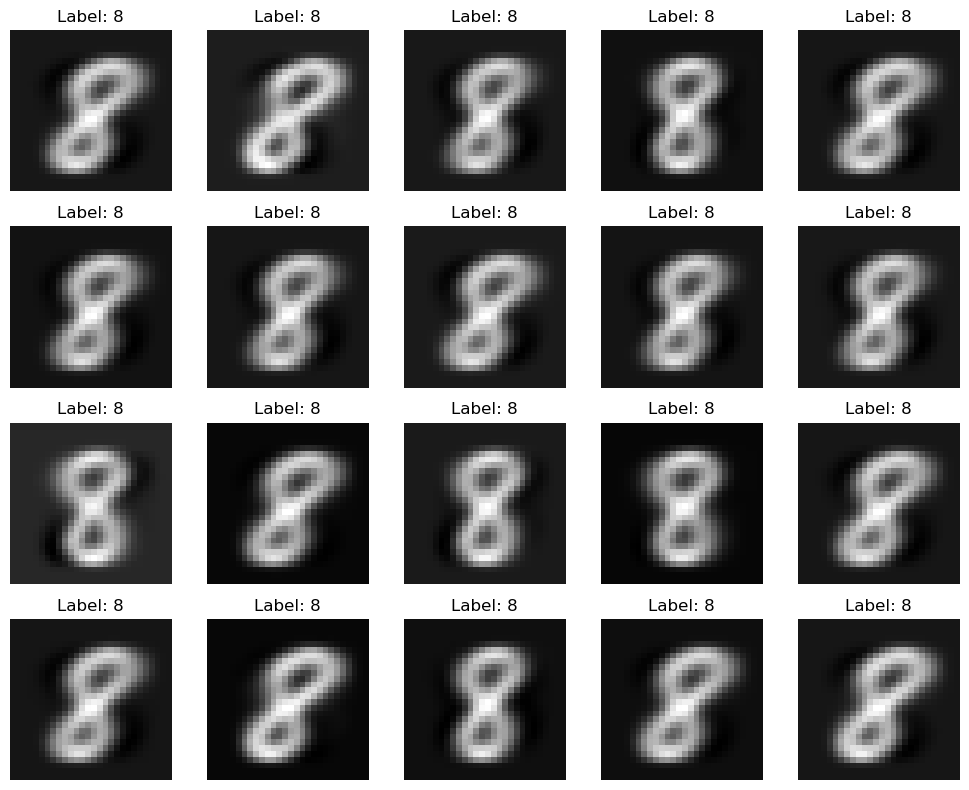

In [31]:
indices = np.where(np.isin(labels, 8))[0]

filtered_imgs = imgs[indices]
filtered_labels = labels[indices]

imgs_recon = project_PCA(filtered_imgs, dim=2)

show_image_grid(imgs_recon, filtered_labels, ids=range(20), cols=5)

### All imgs

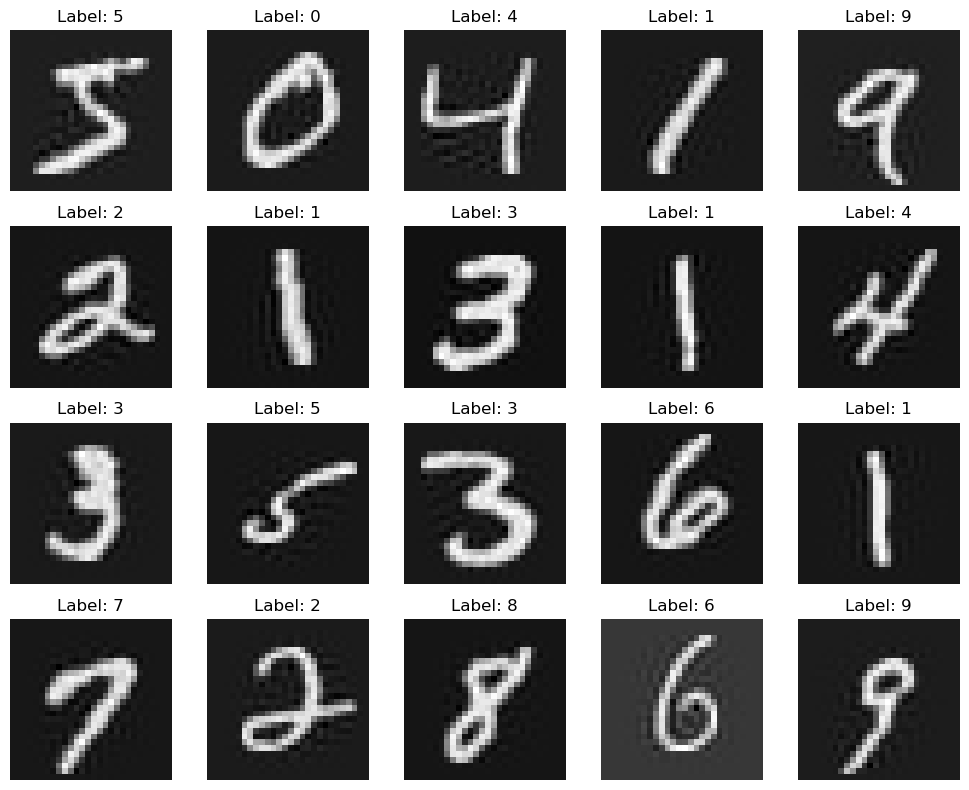

In [34]:
imgs_recon = project_PCA(imgs, dim=500)

show_image_grid(imgs_recon, labels, ids=range(20), cols=5)

## Sample new coordinates in Z and reconstruct

In [ ]:
def project_PCA_noise(imgs, dim, noise_std):
    # 1. Standardization - mean subtraction and dividing by standard deviation 
    N, n_cols, n_rows = imgs.shape[0], imgs.shape[1], imgs.shape[2]
    flat_imgs = imgs.reshape(N, n_cols * n_rows)
    
    mu = np.mean(flat_imgs, axis=0)
    std = np.std(flat_imgs, axis=0)
    std_safe = np.where(std == 0, 1, std)

    standard_flat_imgs = (flat_imgs - mu) / std_safe

    # 2. Compute covariance matrix S = X X.T / N
    X = standard_flat_imgs.T
    S = X @ X.T / N

    eigenvalues, eigenvectors = np.linalg.eigh(S)

    pcds = []
    for i in range(dim):
        pcd = eigenvectors[:, -i-1]
        pcds.append(pcd)

    # 3. Project onto the principal subspace
    B = np.array(pcds).T

    Z = B.T @ X # Coordinates
    noise = np.random.normal(loc=1.0, scale=noise_std, size=Z.shape)
    Z = Z * noise # Disturb to create "new samples"

    x_tilde = B @ Z

    # 4. Project back to original space 
    x_proj = x_tilde.T * std + mu
    
    x_recon = x_proj.reshape(N, n_cols, n_rows)

    return x_recon

### 8s

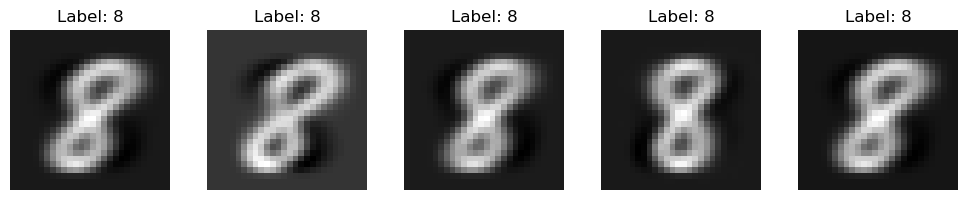

In [35]:
indices = np.where(np.isin(labels, 8))[0]

filtered_imgs = imgs[indices]
filtered_labels = labels[indices]

imgs_recon = project_PCA_noise(filtered_imgs, dim=2, noise_std=0.5)

show_image_grid(imgs_recon, filtered_labels, ids=range(5), cols=5)

### All imgs

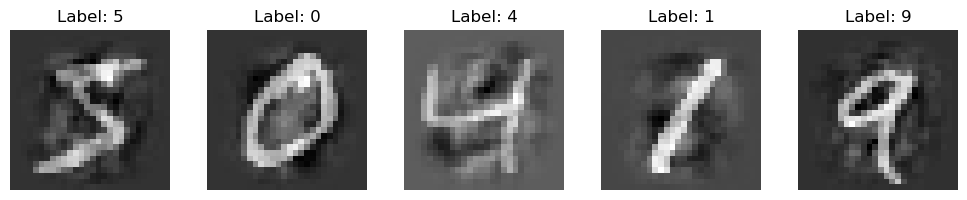

In [36]:
imgs_recon = project_PCA_noise(imgs, dim=700, noise_std=0.5)

show_image_grid(imgs_recon, labels, ids=range(5), cols=5)